# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
from IPython.display import display


In [2]:
# ── Load image ────────────────────────────────────
img_orig = Image.open("cameraman.jpg").convert("RGB")


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
w, h = img_orig.size
print("size:", w, h)

# scaling factors
sx, sy = 2, 2


size: 512 512


In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
img_scaled = img_orig.resize((w * sx, h * sy), Image.Resampling.LANCZOS)


In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
img_scaled.save("task1_1_scaled.jpg")
print("original:", img_orig.size, "scaled:", img_scaled.size)


original: (512, 512) scaled: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
cx, cy = 2, 1
w0, h0 = img_orig.size
img_nu = img_orig.resize((int(w0 * cx), int(h0 * cy)), Image.Resampling.LANCZOS)


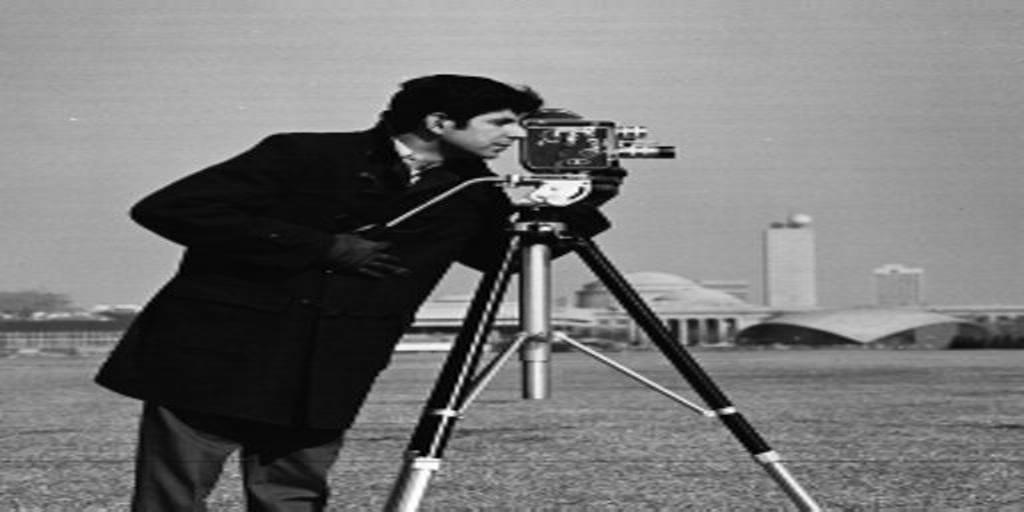

In [7]:
display(img_nu)


In [8]:
print("non-uniform (cx=2, cy=1):", img_nu.size)


non-uniform (cx=2, cy=1): (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
img_rot = img_orig.rotate(120, expand=True, resample=Image.Resampling.BICUBIC)
img_rot.save("task1_2_rotated.jpg")
print("original:", img_orig.size, "rotated:", img_rot.size)


original: (512, 512) rotated: (700, 700)


### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
w0, h0 = img_orig.size


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5
out_w = int(w0 + abs(shx) * h0)
out_h = h0


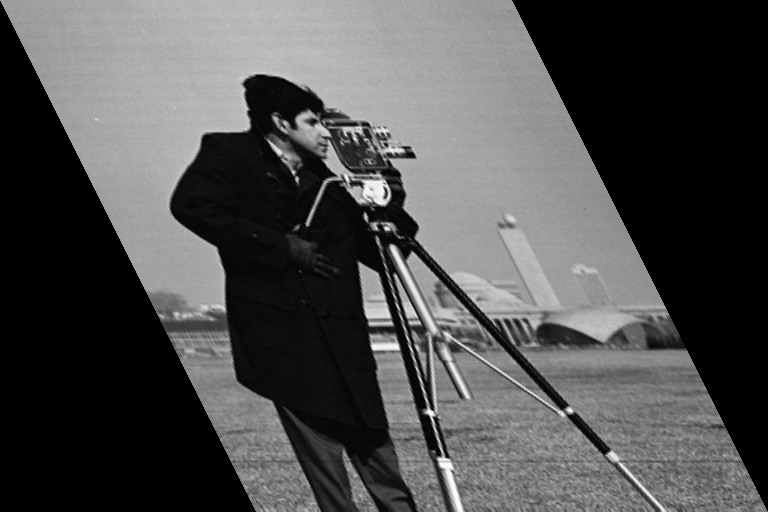

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
img_shear = img_orig.transform(
    (out_w, out_h),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC,
)
display(img_shear)


In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
img_shear.save("task1_3_sheared.jpg")
print("sheared:", img_shear.size)


sheared: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

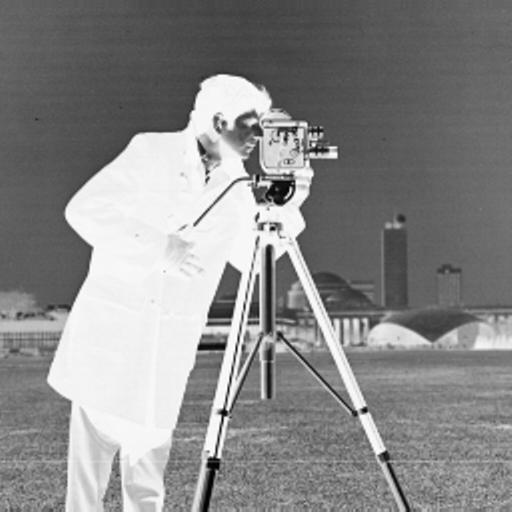

In [14]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr = np.asarray(img_orig)
neg_arr = 255 - arr
img_neg_np = Image.fromarray(neg_arr.astype(np.uint8))
display(img_neg_np)



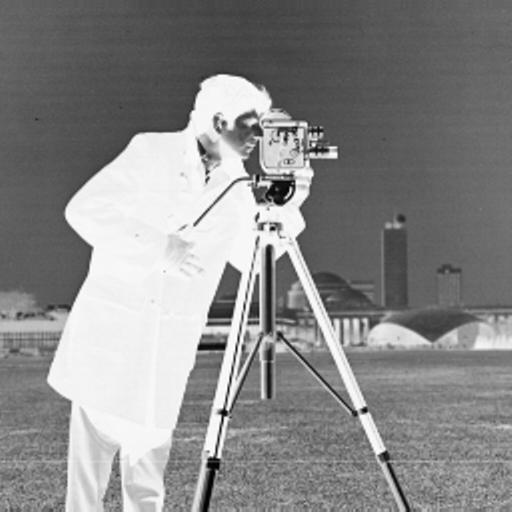

In [15]:
# Method 2: PIL's ImageOps
img_neg_pil = ImageOps.invert(img_orig)
display(img_neg_pil)


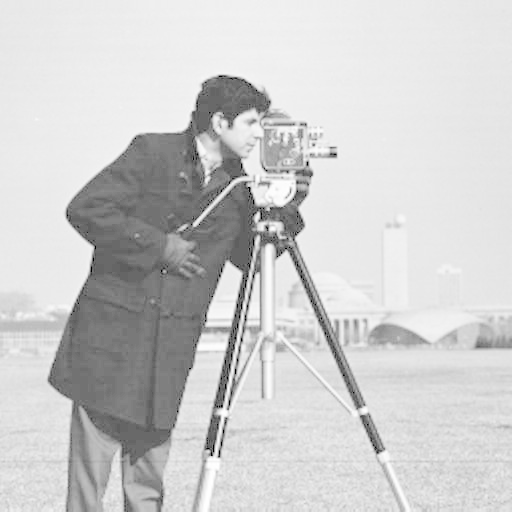

In [16]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel
arr = np.asarray(img_orig, dtype=np.float64)
c = 255.0 / np.log(256.0)
log_arr = np.clip(c * np.log1p(arr), 0, 255).astype(np.uint8)
img_log = Image.fromarray(log_arr)
display(img_log)


In [17]:

# ── 3. Power-law / Gamma correction ───────────────


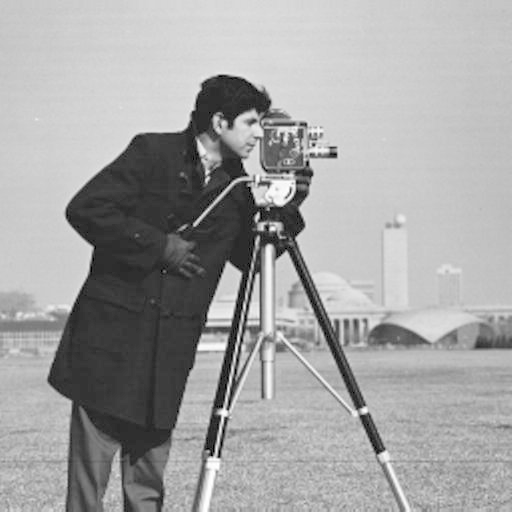

In [18]:
gamma = 0.5
arr = np.asarray(img_orig, dtype=np.float64) / 255.0
gamma_arr = np.clip(arr ** gamma * 255.0, 0, 255).astype(np.uint8)
img_gamma = Image.fromarray(gamma_arr)
display(img_gamma)
